# Exploratory Data Analysis — Synthetic Credit Scoring Dataset (Pakistan)

**Dataset:** `data/synthetic_credit_scoring_dataset.csv` — 10,000 synthetic borrower records replicating the calibration of Khan, Tariq & Khattak (2025), *"AI-Enhanced Credit Scoring Using Alternative Data for Financial Inclusion in Pakistan"* (Table 4.1), extended with a **continuous `repayment_score` target (0–100)** instead of the paper's binary default flag.

**Purpose of this EDA:** understand, validate, visualize and document the dataset's statistical characteristics and relationships **before** machine-learning model training.

**Ground rules obeyed throughout:**
- No ML models are trained and no train/test split is performed.
- The original CSV is never modified (read-only).
- `loan_burden` is created as an EDA-derived analytical variable only.
- Every conclusion below is backed by actual statistics or visualizations from the CSV — nothing is fabricated or "improved".

**Tools:** Python (pandas, numpy, matplotlib, seaborn).

## 2. Load and Inspect the Dataset

Column roles:

| Role | Columns |
|---|---|
| **ID** | `borrower_id` |
| **Main predictors (10)** | `age`, `occupation`, `monthly_income`, `existing_loan_history`, `debt_to_income_ratio`, `loan_size` (moderating variable), `telecom_usage_score`, `mobile_wallet_activity`, `digital_purchase_frequency`, `psychometric_score` |
| **Target** | `repayment_score` (continuous, 0–100) |
| **Demographics (fairness audit only)** | `gender`, `province` |
| **Encoding helper** | `loan_history_code` — a numeric encoding of `existing_loan_history`; it is **not** an independent feature and must not be used alongside its source column |

In [1]:
%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)

# Robust data path: works when the notebook is launched from the project root
DATA_PATH = Path("data/synthetic_credit_scoring_dataset.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path(r"d:\Alibaba hackathon\data\synthetic_credit_scoring_dataset.csv")
FIG_DIR = DATA_PATH.parent.parent / "EDA_Figures"
FIG_DIR.mkdir(exist_ok=True)

def save_fig(fig, name):
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")

df = pd.read_csv(DATA_PATH)
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns from {DATA_PATH}")

Loaded 10,000 rows x 15 columns from data\synthetic_credit_scoring_dataset.csv


In [2]:
print("First 5 rows:")
display(df.head())
print("Last 5 rows:")
display(df.tail())

First 5 rows:


,borrower_id,age,occupation,monthly_income,existing_loan_history,loan_history_code,debt_to_income_ratio,loan_size,telecom_usage_score,mobile_wallet_activity,digital_purchase_frequency,psychometric_score,gender,province,repayment_score
0,PK-00001,41,Daily Wage Worker,43448,Delayed Repayment History,2,0.385,331907,0.523,0.243,2,71.5,Male,Balochistan,23.10
1,PK-00002,28,Self-Employed,43283,No Previous Loan,0,0.185,328705,0.644,0.799,12,40.6,Male,Punjab,63.81
2,PK-00003,45,Daily Wage Worker,54453,No Previous Loan,0,0.078,559967,0.590,0.447,0,54.6,Male,Balochistan,70.00
3,PK-00004,47,Salaried,56228,Good Repayment History,1,0.196,586266,0.550,0.572,2,48.1,Female,Balochistan,65.11
4,PK-00005,19,Self-Employed,64760,No Previous Loan,0,0.179,641506,0.745,0.756,5,59.1,Female,Sindh,49.04


Last 5 rows:


,borrower_id,age,occupation,monthly_income,existing_loan_history,loan_history_code,debt_to_income_ratio,loan_size,telecom_usage_score,mobile_wallet_activity,digital_purchase_frequency,psychometric_score,gender,province,repayment_score
9995,PK-09996,53,Self-Employed,67595,Previous Default,3,0.253,649934,0.554,0.403,0,55.6,Male,Khyber Pakhtunkhwa,20.04
9996,PK-09997,37,Salaried,56021,Delayed Repayment History,2,0.444,310464,0.565,0.683,7,17.5,Female,Punjab,43.37
9997,PK-09998,39,Daily Wage Worker,38361,Good Repayment History,1,0.173,417917,0.342,0.266,0,55.7,Male,Khyber Pakhtunkhwa,30.55
9998,PK-09999,48,Business Owner,103840,Good Repayment History,1,0.206,831403,0.626,0.715,1,44.3,Male,Khyber Pakhtunkhwa,66.07
9999,PK-10000,36,Business Owner,88092,No Previous Loan,0,0.010,665059,0.530,0.512,8,54.6,Male,Punjab,75.72


In [3]:
print("Shape          :", df.shape)
print("Columns        :", list(df.columns))
print("\nData types:")
print(df.dtypes)
print("\nBasic dataset information:")
df.info()

Shape          : (10000, 15)
Columns        : ['borrower_id', 'age', 'occupation', 'monthly_income', 'existing_loan_history', 'loan_history_code', 'debt_to_income_ratio', 'loan_size', 'telecom_usage_score', 'mobile_wallet_activity', 'digital_purchase_frequency', 'psychometric_score', 'gender', 'province', 'repayment_score']

Data types:
borrower_id                    object
age                             int64
occupation                     object
monthly_income                  int64
existing_loan_history          object
loan_history_code               int64
debt_to_income_ratio          float64
loan_size                       int64
telecom_usage_score           float64
mobile_wallet_activity        float64
digital_purchase_frequency      int64
psychometric_score            float64
gender                         object
province                       object
repayment_score               float64
dtype: object

Basic dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex:

## 3. Data Quality Check

Checks performed: missing values, duplicate rows, duplicate borrower IDs, datatype validity, categorical value domains, and numerical ranges against the dataset's design constraints.

In [4]:
print("Missing values (total)               :", int(df.isna().sum().sum()))
print("Missing values per column (non-zero) :", {k: int(v) for k, v in df.isna().sum().items() if v})
print("Duplicate rows (incl. borrower_id)   :", int(df.duplicated().sum()))
print("Duplicate rows (excl. borrower_id)   :", int(df.drop(columns=["borrower_id"]).duplicated().sum()))
print("Duplicate borrower IDs               :", int(df["borrower_id"].duplicated().sum()))

print("\nUnique values of categorical variables:")
for c in ["occupation", "existing_loan_history", "gender", "province"]:
    print(f"  {c:<24}: {sorted(df[c].unique())}")

expected_num = ["age", "monthly_income", "loan_history_code", "debt_to_income_ratio",
                "loan_size", "telecom_usage_score", "mobile_wallet_activity",
                "digital_purchase_frequency", "psychometric_score", "repayment_score"]
expected_cat = ["borrower_id", "occupation", "existing_loan_history", "gender", "province"]
dtypes_ok = (all(pd.api.types.is_numeric_dtype(df[c]) for c in expected_num)
             and all(df[c].dtype == object for c in expected_cat))
print("\nAll expected columns have valid datatypes:", dtypes_ok)

Missing values (total)               : 0
Missing values per column (non-zero) : {}
Duplicate rows (incl. borrower_id)   : 0
Duplicate rows (excl. borrower_id)   : 0
Duplicate borrower IDs               : 0

Unique values of categorical variables:
  occupation              : ['Business Owner', 'Daily Wage Worker', 'Freelancer', 'Other', 'Salaried', 'Self-Employed']
  existing_loan_history   : ['Delayed Repayment History', 'Good Repayment History', 'No Previous Loan', 'Previous Default']
  gender                  : ['Female', 'Male']
  province                : ['Balochistan', 'Khyber Pakhtunkhwa', 'Punjab', 'Sindh']

All expected columns have valid datatypes: True


In [5]:
constraints = [
    ("Age 18-65",                          "age",                   18,       65),
    ("Monthly income 15,000-250,000 PKR",  "monthly_income",     15000,   250000),
    ("Loan size 50,000-1,200,000 PKR",     "loan_size",          50000, 1200000),
    ("DTI 0-1",                            "debt_to_income_ratio", 0.0,     1.0),
    ("Telecom usage score 0.20-0.98",      "telecom_usage_score",  0.20,    0.98),
    ("Mobile wallet activity 0.10-0.95",   "mobile_wallet_activity", 0.10,  0.95),
    ("Psychometric score 0-100",           "psychometric_score",    0,     100),
    ("Repayment score 0-100",              "repayment_score",       0,     100),
]
rows = []
for label, col, lo, hi in constraints:
    ok = bool(df[col].between(lo, hi).all())
    rows.append({"Check": label, "Min": df[col].min(), "Max": df[col].max(),
                 "Expected range": f"[{lo:,}, {hi:,}]", "Result": "PASS" if ok else "FAIL"})
display(pd.DataFrame(rows))

,Check,Min,Max,Expected range,Result
0,Age 18-65,18.00,65.000,"[18, 65]",PASS
1,"Monthly income 15,000-250,000 PKR",15000.00,250000.000,"[15,000, 250,000]",PASS
2,"Loan size 50,000-1,200,000 PKR",50296.00,1200000.000,"[50,000, 1,200,000]",PASS
3,DTI 0-1,0.01,0.681,"[0.0, 1.0]",PASS
4,Telecom usage score 0.20-0.98,0.20,0.980,"[0.2, 0.98]",PASS
5,Mobile wallet activity 0.10-0.95,0.10,0.950,"[0.1, 0.95]",PASS
6,Psychometric score 0-100,3.10,97.000,"[0, 100]",PASS
7,Repayment score 0-100,2.27,97.150,"[0, 100]",PASS


**Quality verdict — the dataset is clean.** Zero missing values, zero duplicate rows, zero duplicate borrower IDs, valid datatypes, and **all 8 range constraints PASS**. The income bounds land exactly on the calibration limits (15,000 / 250,000 PKR) and the loan minimum (50,296 PKR) sits just above the 50,000 micro-loan floor, consistent with the generation design. The repayment score spans 2.27–97.15 with no hard pile-ups at 0 or 100.

## 4. Descriptive Statistics

In [6]:
num_cols = ["age", "monthly_income", "debt_to_income_ratio", "loan_size",
            "telecom_usage_score", "mobile_wallet_activity",
            "digital_purchase_frequency", "psychometric_score", "repayment_score"]
desc = df[num_cols].describe().T
desc["median"] = df[num_cols].median()
desc["skew"] = df[num_cols].skew()
display(desc[["count", "mean", "median", "std", "min", "25%", "75%", "max", "skew"]].round(3))

,count,mean,median,std,min,25%,75%,max,skew
age,10000.0,37.670,38.000,9.315,18.00,31.000,44.000,65.000,0.098
monthly_income,10000.0,68379.928,63321.500,29202.497,15000.00,47336.500,83138.250,250000.000,1.209
debt_to_income_ratio,10000.0,0.181,0.162,0.127,0.01,0.080,0.261,0.681,0.669
loan_size,10000.0,519629.095,494989.000,180317.088,50296.00,391541.000,618462.000,1200000.000,0.834
telecom_usage_score,10000.0,0.610,0.615,0.140,0.20,0.515,0.711,0.980,-0.184
mobile_wallet_activity,10000.0,0.530,0.535,0.189,0.10,0.391,0.670,0.950,-0.076
digital_purchase_frequency,10000.0,5.259,3.000,7.674,0.00,1.000,6.000,45.000,2.828
psychometric_score,10000.0,58.049,58.000,15.533,3.10,47.500,68.600,97.000,-0.029
repayment_score,10000.0,58.129,60.005,17.117,2.27,46.560,71.190,97.150,-0.432


**Observations (simple language):**

- **Income is highly variable and right-skewed** — mean 68,380 vs median 63,322 PKR (skew +1.21); the coefficient of variation is ≈ 0.43, so incomes genuinely differ a lot across borrowers, as in real microfinance populations.
- **Repayment score is concentrated around moderate-to-good values** — mean 58.1, IQR 46.6–71.2; half of all borrowers score between ~47 and ~71.
- **DTI is generally low** — mean 0.18 and 75% of borrowers are at or below 0.26, though the tail reaches 0.68.
- **Loan sizes are widely distributed** — 50,296 to 1,200,000 PKR (24× range), mild right skew (+0.83).
- **Digital purchase frequency is strongly right-skewed** (skew +2.83, median 3 < mean 5.26) — expected for count data where most people make few purchases.
- Telecom score, wallet activity and psychometric score are roughly symmetric (|skew| ≤ 0.19), each using nearly its full designed range.

## 5. Categorical Variable Analysis

Frequency counts, percentages and bar charts for `occupation`, `existing_loan_history`, `gender` and `province` (the categorical form of loan history is used for visualization — `loan_history_code` is not treated as a separate feature).

In [7]:
for c in ["occupation", "existing_loan_history", "gender", "province"]:
    vc = df[c].value_counts()
    tbl = pd.DataFrame({"count": vc, "pct": (vc / len(df)).map("{:.1%}".format)})
    print(f"\n{c}:")
    display(tbl)


occupation:


,count,pct
occupation,,
Self-Employed,2548,25.5%
Salaried,2169,21.7%
Daily Wage Worker,2024,20.2%
Business Owner,1825,18.2%
Freelancer,833,8.3%
Other,601,6.0%



existing_loan_history:


,count,pct
existing_loan_history,,
No Previous Loan,4686,46.9%
Good Repayment History,2985,29.8%
Delayed Repayment History,1641,16.4%
Previous Default,688,6.9%



gender:


,count,pct
gender,,
Male,6149,61.5%
Female,3851,38.5%



province:


,count,pct
province,,
Punjab,5286,52.9%
Sindh,2309,23.1%
Khyber Pakhtunkhwa,1699,17.0%
Balochistan,706,7.1%


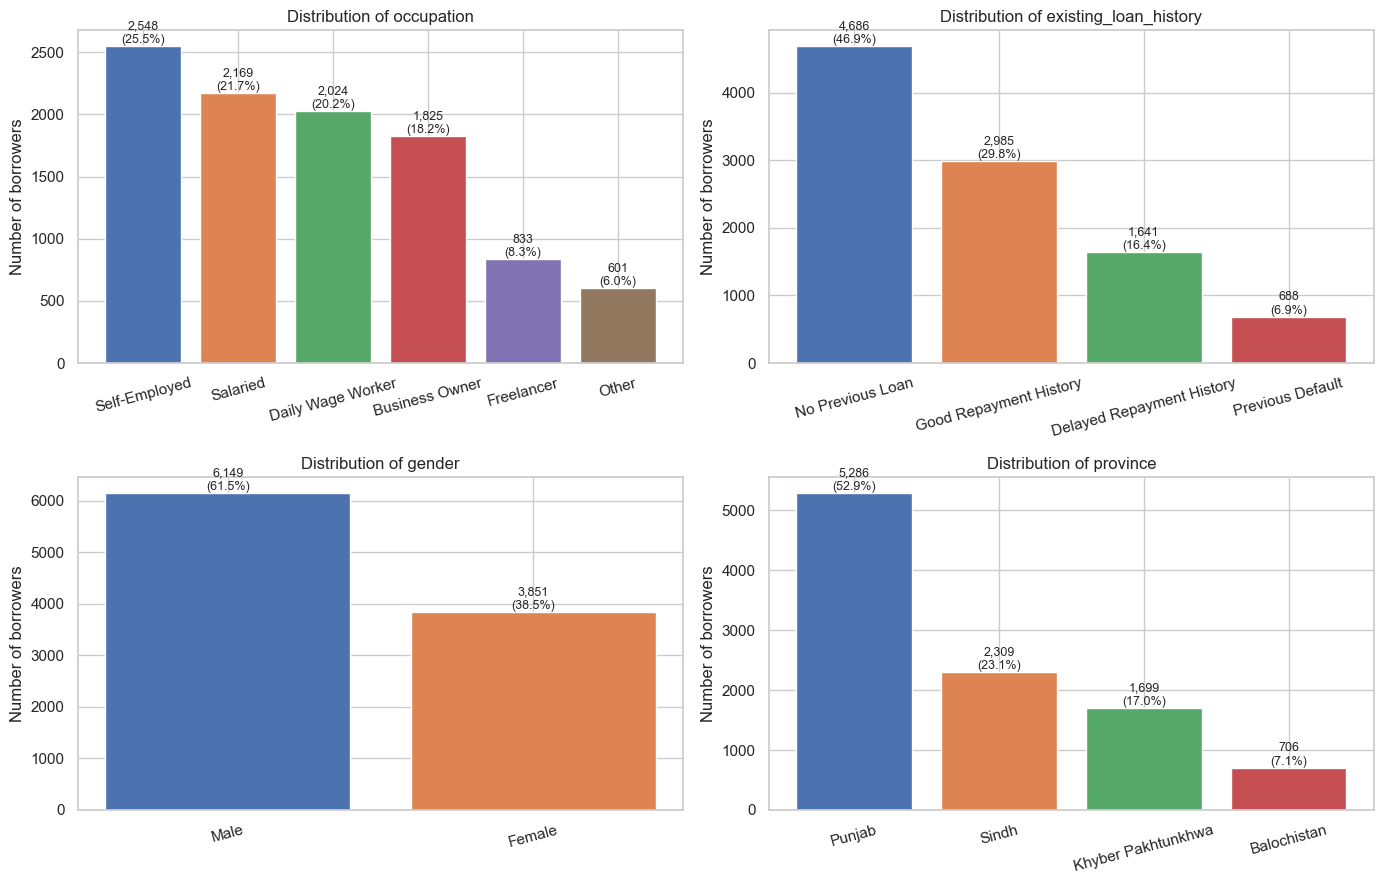

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, c in zip(axes.ravel(), ["occupation", "existing_loan_history", "gender", "province"]):
    vc = df[c].value_counts()
    bars = ax.bar(vc.index.astype(str), vc.values,
                  color=sns.color_palette("deep", len(vc)))
    ax.set_title(f"Distribution of {c}")
    ax.set_ylabel("Number of borrowers")
    for bar, v in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:,}\n({v/len(df):.1%})",
                ha="center", va="bottom", fontsize=9)
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

**Interpretation:**

- **Occupation:** Self-Employed is the largest group (25.5%), followed by Salaried (21.7%), Daily Wage Worker (20.2%) and Business Owner (18.2%) — a plausible mix for individual/microenterprise lending. Freelancer (8.3%) and Other (6.0%) are small.
- **Loan history:** almost half the population (46.9%) has **No Previous Loan** — precisely the "credit-invisible" segment this project targets. 29.8% have a good record, while 23.3% show impairment (16.4% delayed + 6.9% previous default).
- **Gender:** 61.5% male / 38.5% female.
- **Province:** Punjab 52.9%, Sindh 23.1%, KP 17.0%, Balochistan 7.1% — proportions consistent with Pakistan's population distribution used in the generation design.

## 6. Univariate Analysis

Distributions of every important numerical variable (histogram + KDE, then boxplots for spread/outlier visibility).

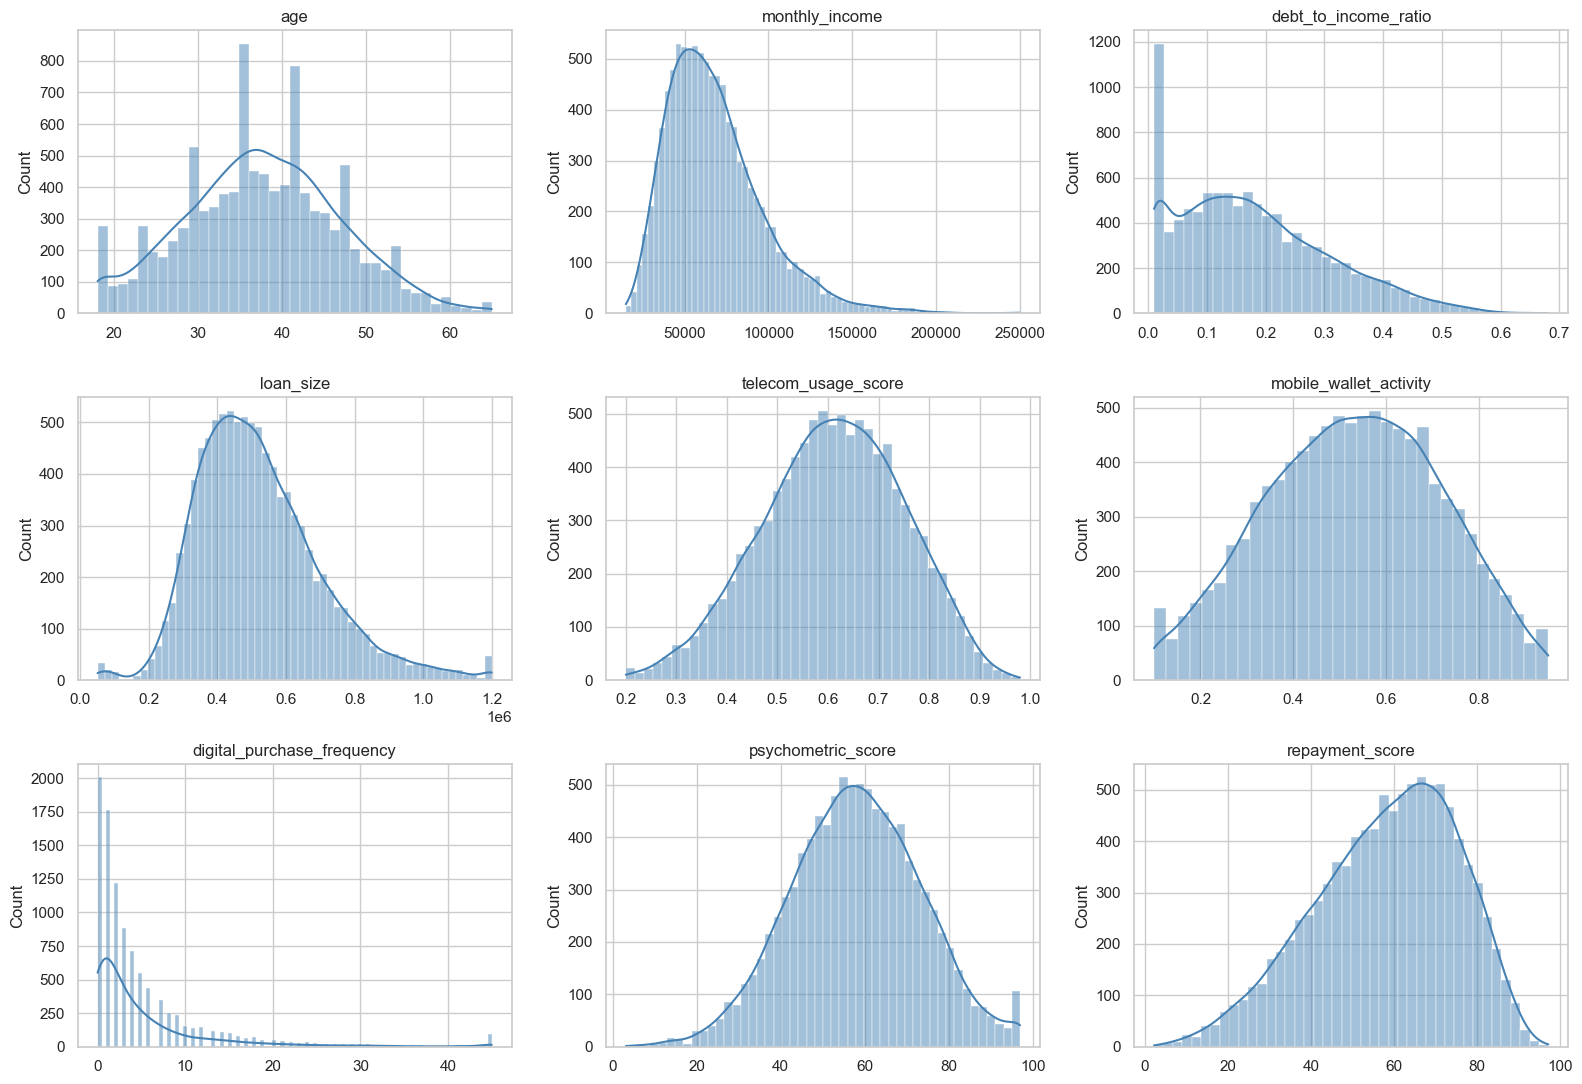

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
for ax, c in zip(axes.ravel(), num_cols):
    sns.histplot(df[c], kde=True, ax=ax, color="steelblue", edgecolor="white", linewidth=0.3)
    ax.set_title(c)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

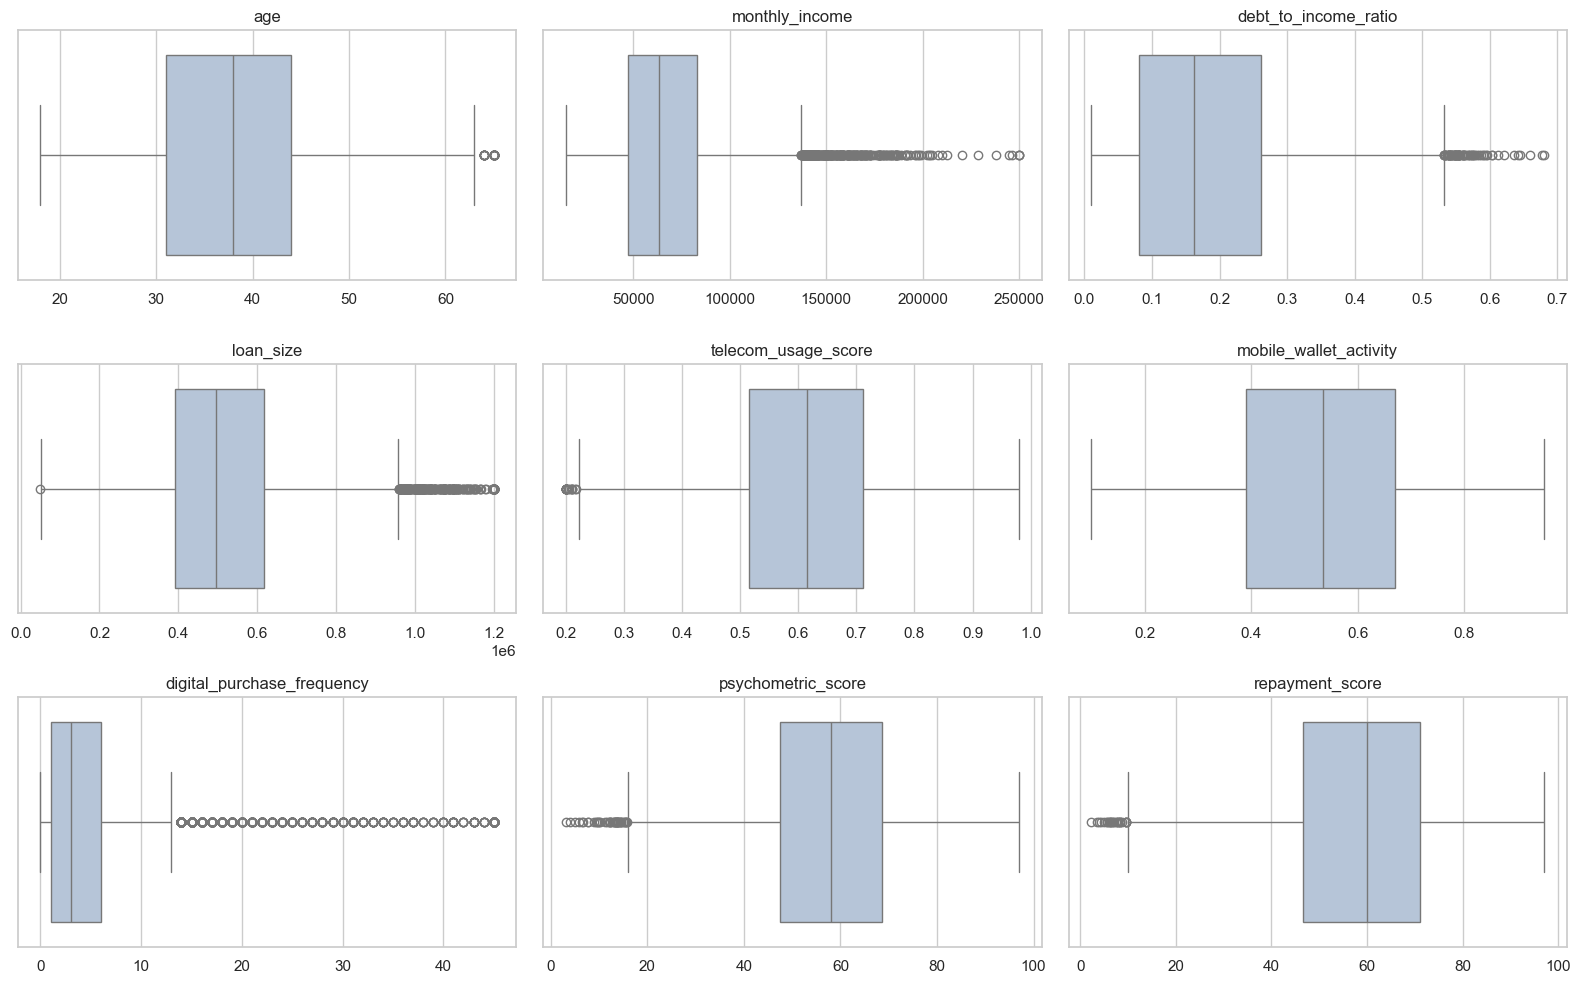

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
for ax, c in zip(axes.ravel(), num_cols):
    sns.boxplot(x=df[c], ax=ax, color="lightsteelblue")
    ax.set_title(c)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

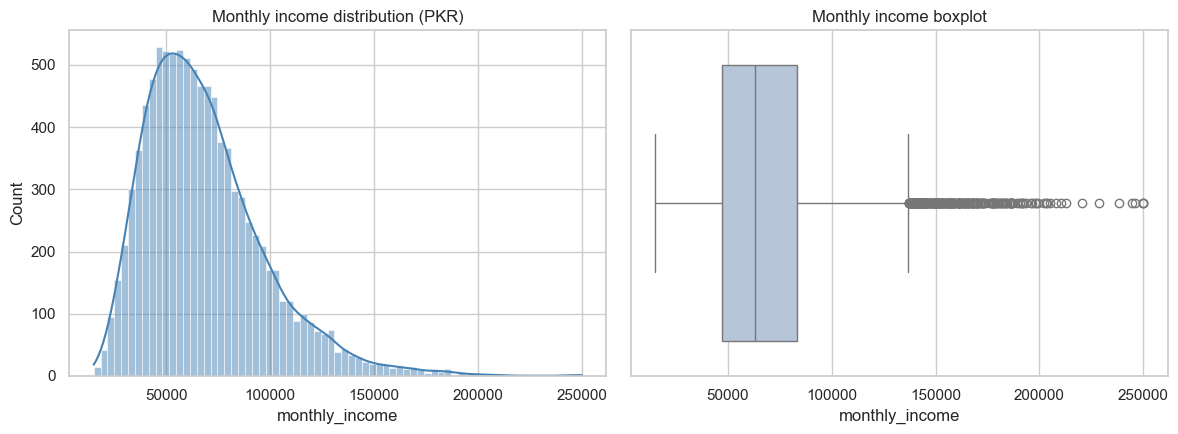

In [11]:
# Dedicated income figure (saved for the report)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df["monthly_income"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Monthly income distribution (PKR)")
sns.boxplot(x=df["monthly_income"], ax=axes[1], color="lightsteelblue")
axes[1].set_title("Monthly income boxplot")
plt.tight_layout()
save_fig(fig, "income_distribution.png")
plt.show()

**Per-variable notes:**

1. **Age** — symmetric bell between 18 and 65 (median 38, skew +0.10); no outliers; realistic working-age lending population.
2. **Monthly income** — right-skewed (skew +1.21) with a long upper tail to 250,000 PKR; the boxplot flags ~2.7% high-side points, which are legitimate high earners, not data errors.
3. **DTI** — right-skewed (+0.67); the bulk sits at 0.05–0.26 with a modest high-debt tail to 0.68.
4. **Loan size** — mild right skew (+0.83), continuous spread from ~50k to 1.2M; no gaps or spikes.
5. **Telecom usage score** — near-symmetric (−0.18), full use of the 0.20–0.98 range.
6. **Mobile wallet activity** — near-symmetric (−0.08), full use of the 0.10–0.95 range.
7. **Digital purchase frequency** — discrete counts, strongly right-skewed (+2.83): a large mass at 0–6 purchases/month and a long tail to 45. Unusual high values are unusual but valid.
8. **Psychometric score** — symmetric bell (−0.03) between 3.1 and 97.
9. **Repayment score** — unimodal, centered near 60, mild left skew (−0.43) with thin tails on both sides — a plausible credit-score shape rather than a uniform or two-humped artifact.

All distributions appear reasonable for their variable type; none show signs of invalid data (negative values, impossible spikes, or truncation pile-ups).

## 7. Target Variable Analysis — `repayment_score`

The target is **continuous (0–100)**. It is analyzed as-is — no binarization, since the downstream task is regression/scoring.

In [12]:
rs = df["repayment_score"]
print(f"Mean   : {rs.mean():.3f}")
print(f"Median : {rs.median():.3f}")
print(f"Std    : {rs.std():.3f}")
print(f"Min/Max: {rs.min():.2f} / {rs.max():.2f}")
print(f"Skew   : {rs.skew():.3f}")
print("\nPercentiles:")
for q in [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]:
    print(f"  p{int(q*100):02d} = {rs.quantile(q):8.2f}")

Mean   : 58.129
Median : 60.005
Std    : 17.117
Min/Max: 2.27 / 97.15
Skew   : -0.432

Percentiles:
  p01 =    15.66
  p05 =    27.07
  p25 =    46.56
  p50 =    60.00
  p75 =    71.19
  p95 =    83.14
  p99 =    88.85


,count,pct
repayment_score,,
0-20\nVery Low,199,2.0%
21-40\nLow,1431,14.3%
41-60\nModerate,3370,33.7%
61-80\nHigh,4114,41.1%
81-100\nVery High,886,8.9%


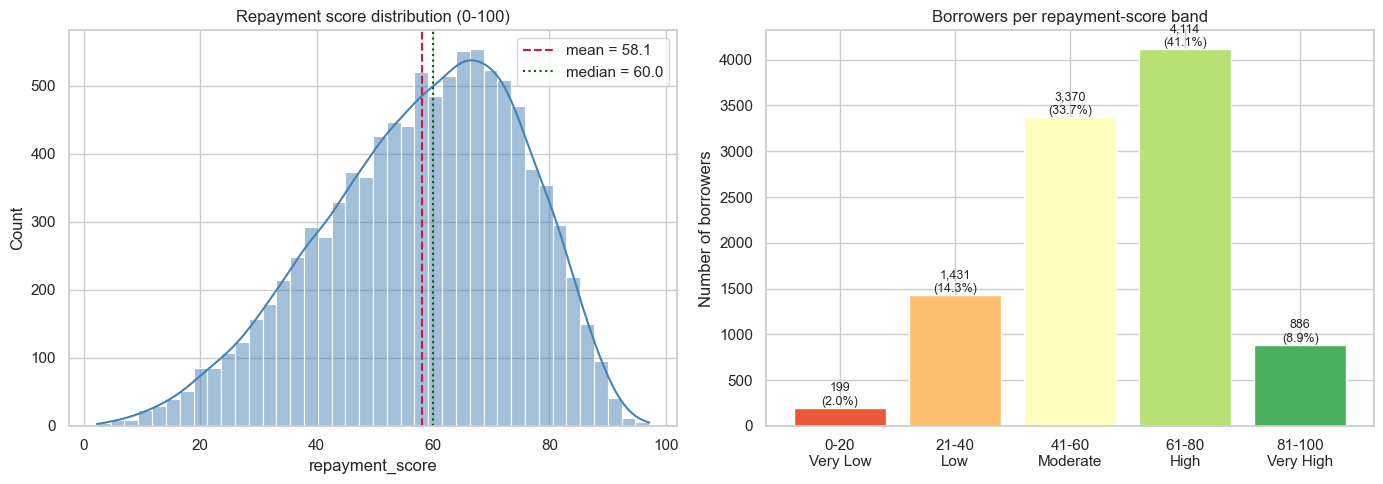

In [13]:
bands = pd.cut(rs, bins=[0, 20, 40, 60, 80, 100],
               labels=["0-20\nVery Low", "21-40\nLow", "41-60\nModerate",
                       "61-80\nHigh", "81-100\nVery High"],
               include_lowest=True)
band_tbl = bands.value_counts().reindex(["0-20\nVery Low", "21-40\nLow", "41-60\nModerate",
                                         "61-80\nHigh", "81-100\nVery High"])
display(pd.DataFrame({"count": band_tbl, "pct": (band_tbl / len(df)).map("{:.1%}".format)}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(rs, kde=True, bins=40, ax=axes[0], color="steelblue")
axes[0].axvline(rs.mean(), color="crimson", ls="--", lw=1.5, label=f"mean = {rs.mean():.1f}")
axes[0].axvline(rs.median(), color="darkgreen", ls=":", lw=1.5, label=f"median = {rs.median():.1f}")
axes[0].set_title("Repayment score distribution (0-100)")
axes[0].legend()
bars = axes[1].bar(band_tbl.index.astype(str), band_tbl.values,
                   color=sns.color_palette("RdYlGn", 5))
for bar, v in zip(bars, band_tbl.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v, f"{v:,}\n({v/len(df):.1%})",
                 ha="center", va="bottom", fontsize=9)
axes[1].set_title("Borrowers per repayment-score band")
axes[1].set_ylabel("Number of borrowers")
plt.tight_layout()
save_fig(fig, "repayment_score_distribution.png")
plt.show()

**Interpretation:** the target is unimodal and centered on moderate-to-good values — mean 58.1, median 60.0, std 17.1, mild left skew (−0.43). The middle 90% of borrowers score between 27.1 (p05) and 83.1 (p95). Band shares: **Very Low 2.0% · Low 14.3% · Moderate 33.7% · High 41.1% · Very High 8.9%** — a realistic credit-score shape with thin extremes, suitable for a continuous regression/scoring problem.

## 8. Numerical Feature vs Repayment Score

Pearson and Spearman correlations plus scatter plots with OLS trend lines for the eight numerical predictors. Expected directions are treated as hypotheses; the values below are what the data actually shows.

In [14]:
preds = ["monthly_income", "debt_to_income_ratio", "telecom_usage_score",
         "mobile_wallet_activity", "digital_purchase_frequency",
         "psychometric_score", "loan_size", "age"]
rows = []
for c in preds:
    rows.append({"predictor": c,
                 "Pearson r": df[c].corr(df["repayment_score"]),
                 "Spearman rho": df[c].corr(df["repayment_score"], method="spearman")})
display(pd.DataFrame(rows).set_index("predictor").round(3))

,Pearson r,Spearman rho
predictor,,
monthly_income,0.384,0.404
debt_to_income_ratio,-0.486,-0.440
telecom_usage_score,0.300,0.290
mobile_wallet_activity,0.300,0.297
digital_purchase_frequency,0.254,0.338
psychometric_score,0.341,0.334
loan_size,-0.035,-0.020
age,-0.036,-0.030


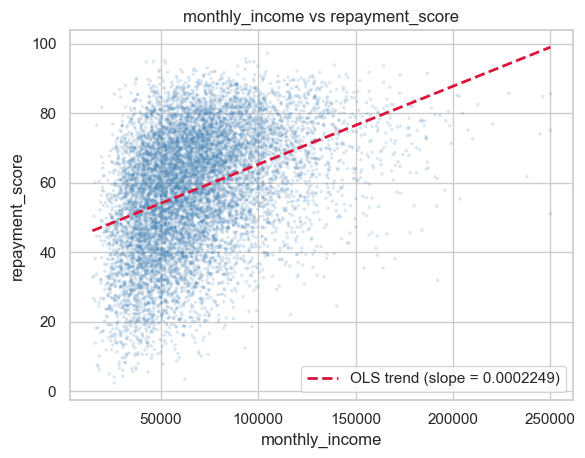

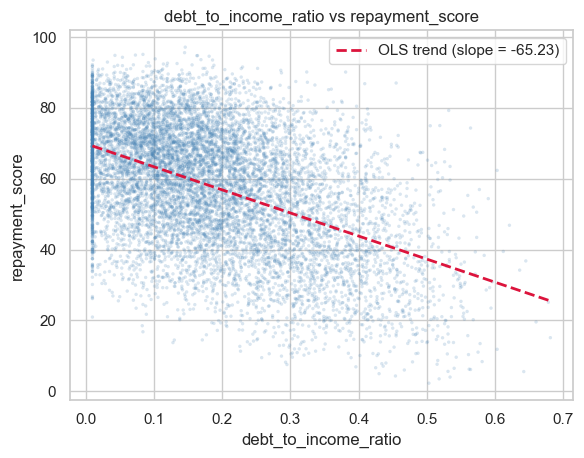

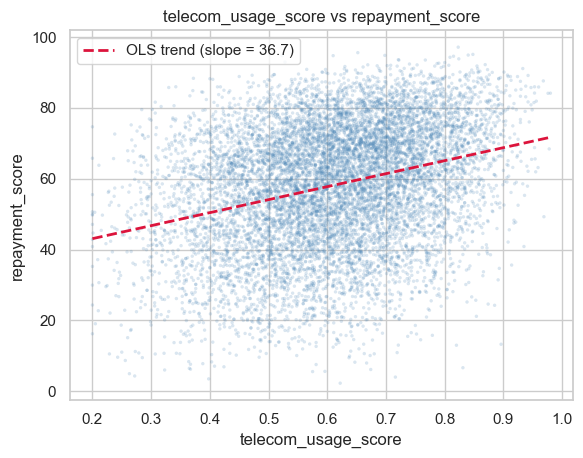

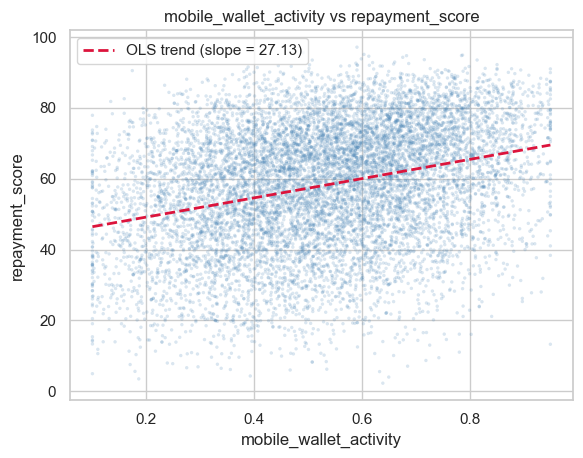

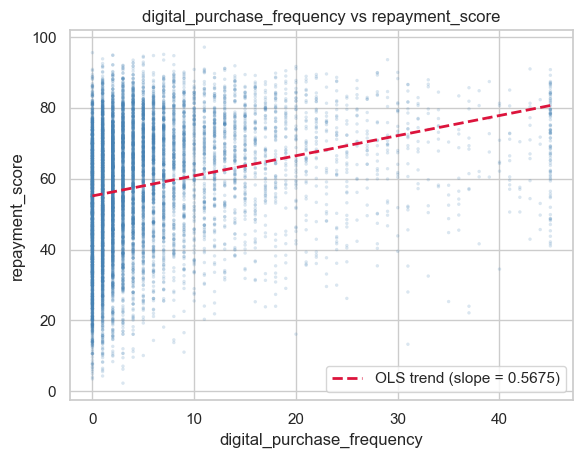

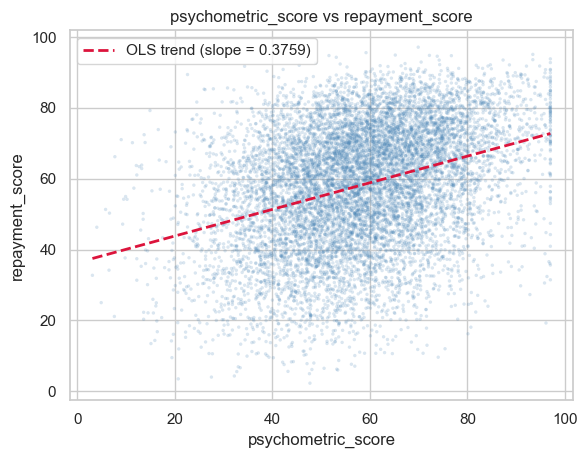

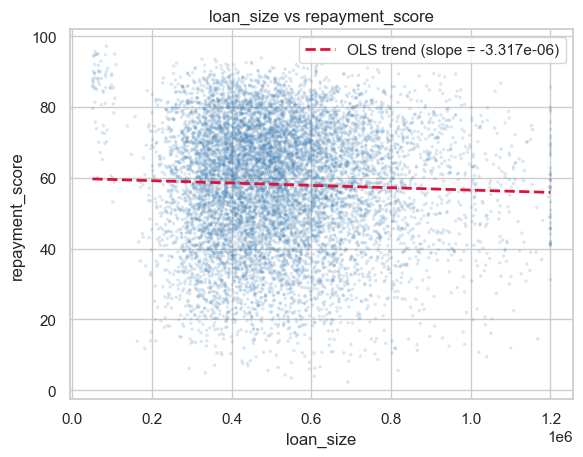

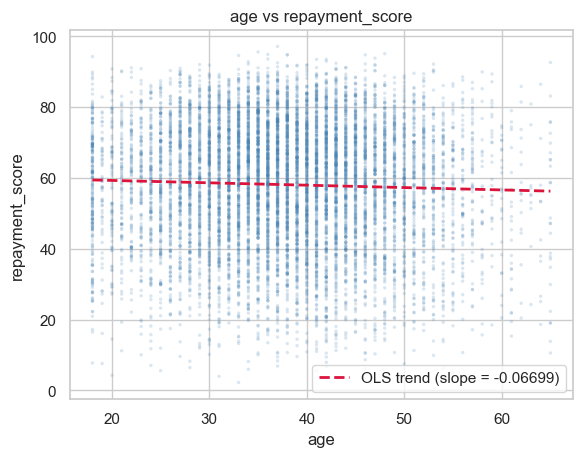

In [15]:
save_names = {"monthly_income": "income_vs_repayment_score.png",
              "debt_to_income_ratio": "dti_vs_repayment_score.png"}
for col in preds:
    fig, ax = plt.subplots(figsize=(6.5, 4.8))
    ax.scatter(df[col], df["repayment_score"], s=6, alpha=0.2,
               color="steelblue", edgecolors="none")
    m, b = np.polyfit(df[col], df["repayment_score"], 1)
    xs = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(xs, m * xs + b, color="crimson", lw=2, ls="--",
            label=f"OLS trend (slope = {m:.4g})")
    ax.set_xlabel(col)
    ax.set_ylabel("repayment_score")
    ax.set_title(f"{col} vs repayment_score")
    ax.legend()
    if col in save_names:
        save_fig(fig, save_names[col])
    plt.show()

**Actual relationships found:**

| Predictor | Pearson | Spearman | Reading |
|---|---|---|---|
| `debt_to_income_ratio` | **−0.486** | −0.440 | Strongest single predictor — more existing debt, lower score |
| `monthly_income` | **+0.384** | +0.404 | Clear positive; capacity effect partially flows through loan burden (see §15) |
| `psychometric_score` | +0.341 | +0.334 | Moderate positive |
| `telecom_usage_score` | +0.300 | +0.290 | Moderate positive |
| `mobile_wallet_activity` | +0.300 | +0.297 | Moderate positive |
| `digital_purchase_frequency` | +0.254 | **+0.338** | Positive but nonlinear — Spearman ≫ Pearson; see §16 |
| `loan_size` | −0.035 | −0.020 | **Almost no direct marginal relationship** — its effect is conditional on income (loan burden), exactly as designed for a moderating variable |
| `age` | −0.036 | −0.030 | Nearly zero linearly; mild nonlinear decline at older ages (see §16) |

The alternative-data block (telecom +0.30, wallet +0.30, purchases +0.25, psychometrics +0.34) each carries moderate, independent-looking signal — supporting the project's premise that digital footprints can substitute for missing credit history.

## 9. Correlation Matrix

Pearson (left) and Spearman (right) matrices for all numerical variables. Correlation does **not** imply causation.

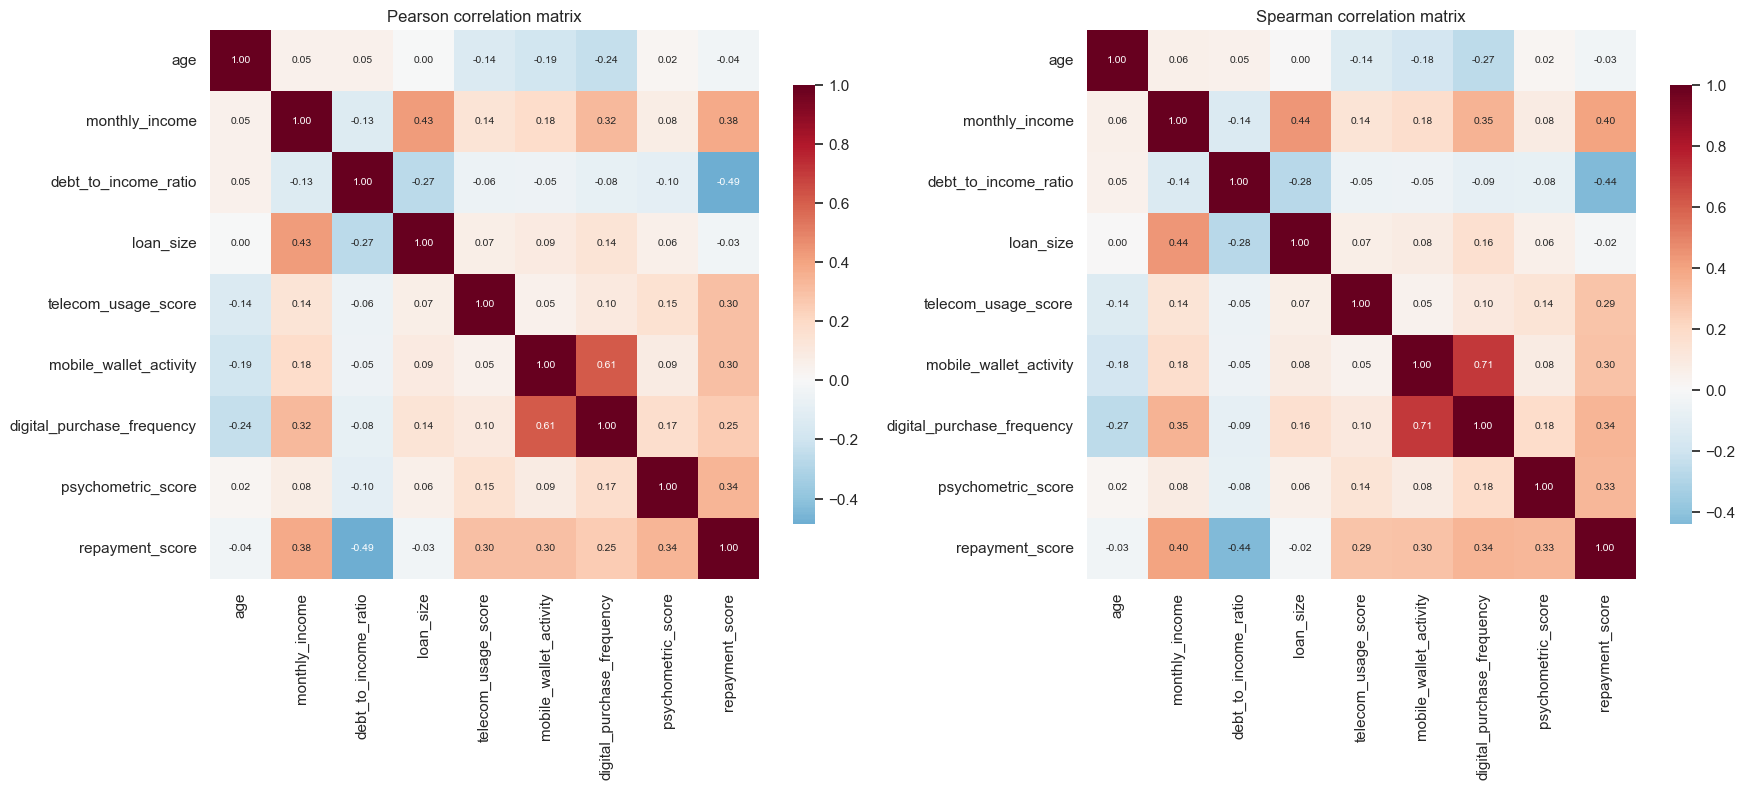

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))
for ax, method in zip(axes, ["pearson", "spearman"]):
    corr = df[num_cols].corr(method=method)
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True,
                annot_kws={"size": 7.5}, ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title(f"{method.title()} correlation matrix")
plt.tight_layout()
save_fig(fig, "correlation_heatmap.png")
plt.show()

**Matrix highlights:**

- **Strong positive:** `mobile_wallet_activity ↔ digital_purchase_frequency` **+0.611** (Spearman +0.706) — wallet intensity drives digital spending; the strongest feature-feature link and the main **multicollinearity concern** for linear models.
- **Moderate positive:** `monthly_income ↔ loan_size` +0.430 (larger incomes request larger loans); `monthly_income ↔ digital_purchase_frequency` +0.324.
- **Strong negative with the target:** `debt_to_income_ratio ↔ repayment_score` −0.486.
- **Weak relationships:** `age` is only weakly associated with everything except digital behavior (age ↔ purchases −0.242, age ↔ wallet −0.192); `monthly_income ↔ DTI` is weak (−0.132) because DTI is driven mainly by loan-history category, not income.
- **Multicollinearity check:** no pair exceeds |r| = 0.7, so no severe collinearity, but the wallet–purchases pair (~0.61–0.71) warrants attention in linear baselines; tree ensembles handle it natively.

## 10. Feature-to-Feature Relationships

Four relationships of conceptual interest (loans vs income, income vs debt, wallet vs purchases, loan vs debt).

monthly_income <-> loan_size: Pearson = +0.430, Spearman = +0.441
monthly_income <-> debt_to_income_ratio: Pearson = -0.132, Spearman = -0.142
mobile_wallet_activity <-> digital_purchase_frequency: Pearson = +0.611, Spearman = +0.706
loan_size <-> debt_to_income_ratio: Pearson = -0.270, Spearman = -0.276


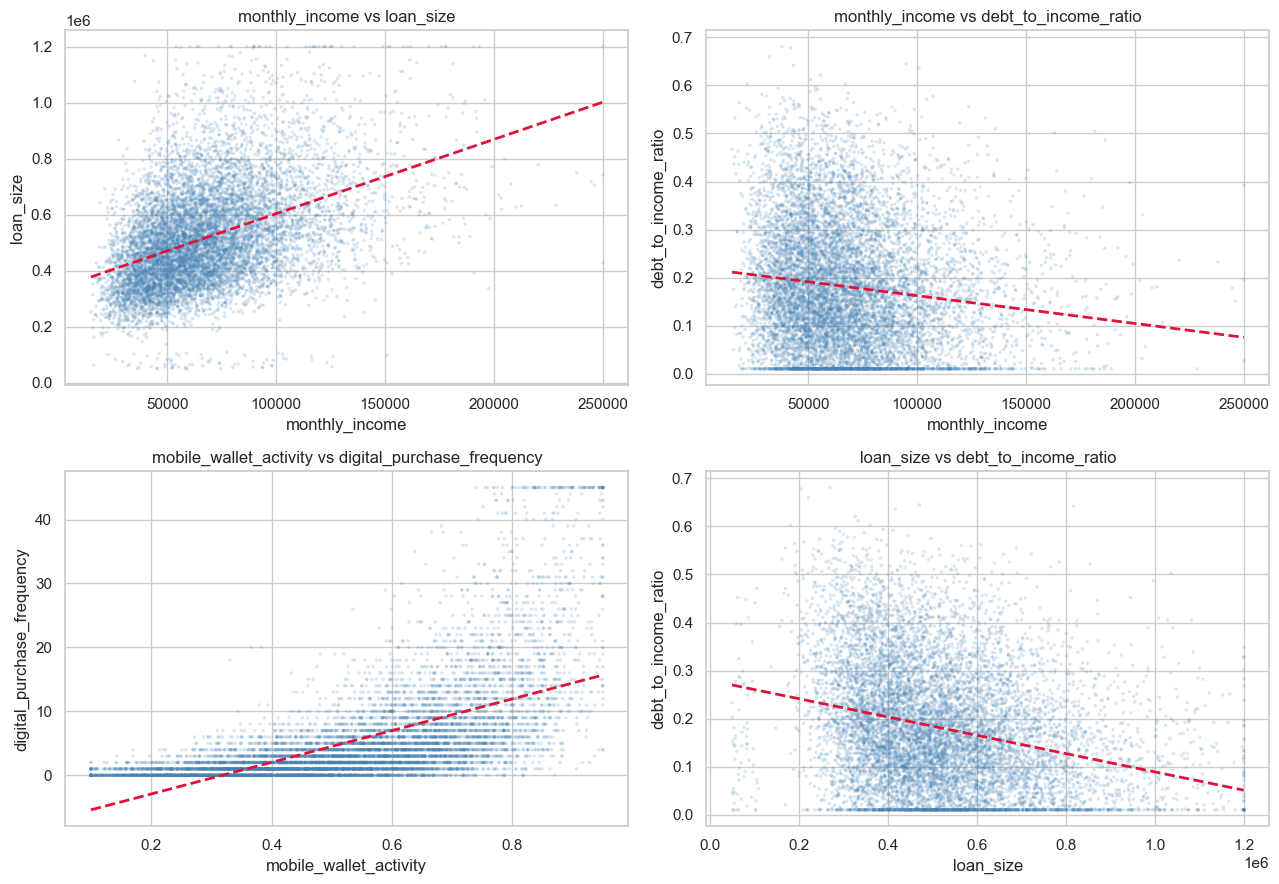

In [17]:
pairs = [("monthly_income", "loan_size"),
         ("monthly_income", "debt_to_income_ratio"),
         ("mobile_wallet_activity", "digital_purchase_frequency"),
         ("loan_size", "debt_to_income_ratio")]
for a, b in pairs:
    print(f"{a} <-> {b}: Pearson = {df[a].corr(df[b]):+.3f}, "
          f"Spearman = {df[a].corr(df[b], method='spearman'):+.3f}")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (a, b) in zip(axes.ravel(), pairs):
    ax.scatter(df[a], df[b], s=6, alpha=0.2, color="steelblue", edgecolors="none")
    m, k = np.polyfit(df[a], df[b], 1)
    xs = np.linspace(df[a].min(), df[a].max(), 100)
    ax.plot(xs, m * xs + k, color="crimson", lw=2, ls="--")
    ax.set_xlabel(a)
    ax.set_ylabel(b)
    ax.set_title(f"{a} vs {b}")
plt.tight_layout()
plt.show()

**Findings:**

1. **Income → Loan size (+0.430):** larger-income borrowers tend to request/receive larger loans, though with substantial spread — loan size is not mechanically determined by income.
2. **Income → DTI (−0.132, weak):** lower-income borrowers are only slightly more indebted; DTI variation is dominated by loan-history category (mean DTI: No Previous Loan 0.10 vs Previous Default 0.41).
3. **Wallet activity → Digital purchases (+0.611 / Spearman +0.706):** the strongest feature-feature relationship — heavier wallet users make noticeably more digital purchases, as expected for a digital-behavior construct.
4. **Loan size → DTI (−0.270):** more-indebted borrowers qualify for somewhat smaller requested loans — a mild supply-side realism built into the data.

## 11. Occupation Analysis

Borrower counts, income, DTI and repayment score by occupation.

In [18]:
occ = df.groupby("occupation").agg(
    n=("borrower_id", "count"),
    mean_income=("monthly_income", "mean"),
    median_income=("monthly_income", "median"),
    mean_dti=("debt_to_income_ratio", "mean"),
    mean_score=("repayment_score", "mean"),
    median_score=("repayment_score", "median"),
).sort_values("mean_score", ascending=False)
occ.insert(1, "pct", (occ["n"] / len(df)).map("{:.1%}".format))
display(occ.round(2))

,n,pct,mean_income,median_income,mean_dti,mean_score,median_score
occupation,,,,,,,
Business Owner,1825,18.2%,90245.78,84952.0,0.17,62.96,64.87
Salaried,2169,21.7%,69275.17,65501.0,0.18,60.56,62.50
Self-Employed,2548,25.5%,71932.57,67993.0,0.18,59.01,61.00
Freelancer,833,8.3%,67367.01,61033.0,0.18,56.79,58.23
Other,601,6.0%,57730.89,54910.0,0.19,55.27,57.05
Daily Wage Worker,2024,20.2%,46811.12,43792.5,0.20,51.46,52.09


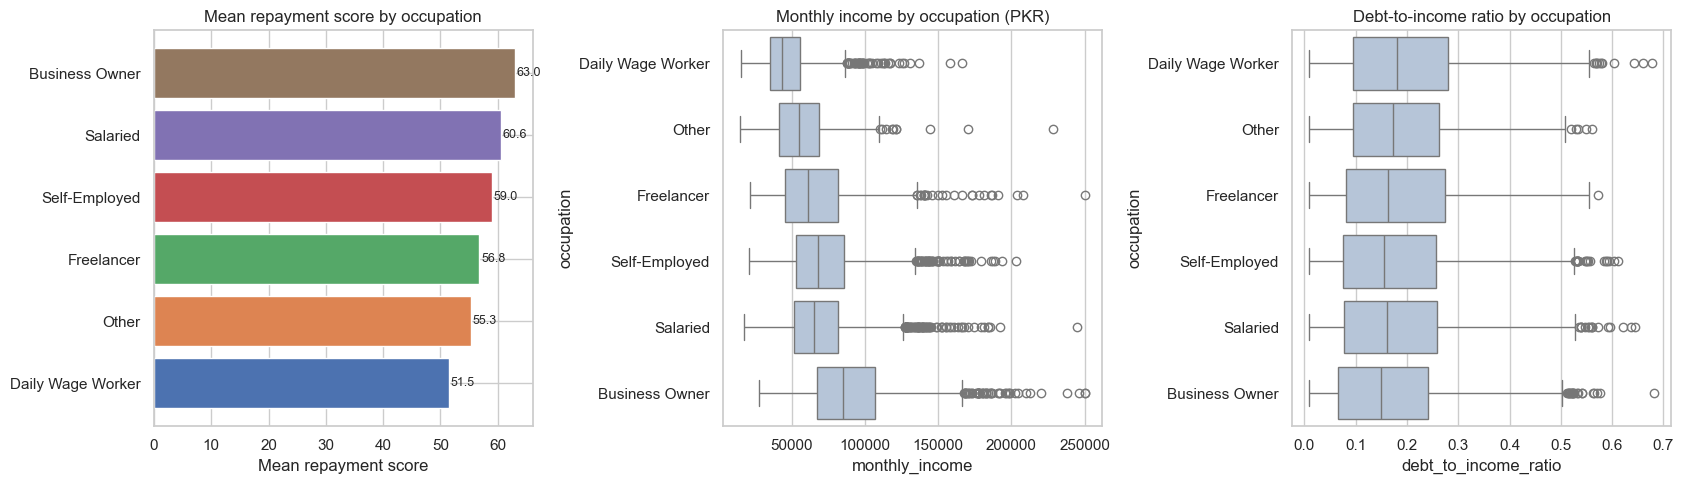

In [19]:
order = occ.sort_values("mean_score").index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
axes[0].barh(order, occ.loc[order, "mean_score"], color=sns.color_palette("deep", len(order)))
axes[0].set_xlabel("Mean repayment score")
axes[0].set_title("Mean repayment score by occupation")
for i, v in enumerate(occ.loc[order, "mean_score"]):
    axes[0].text(v + 0.3, i, f"{v:.1f}", va="center", fontsize=9)
sns.boxplot(data=df, y="occupation", x="monthly_income", order=order, ax=axes[1],
            color="lightsteelblue")
axes[1].set_title("Monthly income by occupation (PKR)")
sns.boxplot(data=df, y="occupation", x="debt_to_income_ratio", order=order, ax=axes[2],
            color="lightsteelblue")
axes[2].set_title("Debt-to-income ratio by occupation")
plt.tight_layout()
save_fig(fig, "occupation_repayment_score.png")
plt.show()

**Interpretation:** occupation is clearly **associated** with repayment score, in a ~11.5-point ordering: Business Owner 62.96 > Salaried 60.56 > Self-Employed 59.01 > Freelancer 56.79 > Other 55.27 > Daily Wage Worker 51.46. The ordering tracks income almost perfectly (Business Owners average 90,246 PKR vs Daily Wage Workers 46,811 PKR), while mean DTI is nearly flat across occupations (0.17–0.20) — so the occupation effect operates mainly through income capacity, not through debt levels. This is an association; no causality is claimed.

## 12. Loan History Analysis

Repayment score by prior-borrowing category, plus a verification that `loan_history_code` is a perfectly consistent encoding of `existing_loan_history`.

In [20]:
hist = df.groupby("existing_loan_history").agg(
    n=("borrower_id", "count"),
    mean_score=("repayment_score", "mean"),
    median_score=("repayment_score", "median"),
    mean_dti=("debt_to_income_ratio", "mean"),
).sort_values("mean_score", ascending=False)
hist.insert(1, "pct", (hist["n"] / len(df)).map("{:.1%}".format))
display(hist.round(2))

ct = pd.crosstab(df["existing_loan_history"], df["loan_history_code"])
print("\nCrosstab: existing_loan_history (rows) vs loan_history_code (columns):")
display(ct)
one_to_one = (((ct > 0).sum(axis=1) == 1).all() and ((ct > 0).sum(axis=0) == 1).all())
print("loan_history_code is a perfect 1:1 encoding of existing_loan_history:", one_to_one)

,n,pct,mean_score,median_score,mean_dti
existing_loan_history,,,,,
Good Repayment History,2985,29.8%,64.85,66.69,0.18
No Previous Loan,4686,46.9%,61.13,62.49,0.10
Delayed Repayment History,1641,16.4%,46.17,45.92,0.31
Previous Default,688,6.9%,37.07,35.64,0.41



Crosstab: existing_loan_history (rows) vs loan_history_code (columns):


loan_history_code,0,1,2,3
existing_loan_history,,,,
Delayed Repayment History,0,0,1641,0
Good Repayment History,0,2985,0,0
No Previous Loan,4686,0,0,0
Previous Default,0,0,0,688


loan_history_code is a perfect 1:1 encoding of existing_loan_history: True


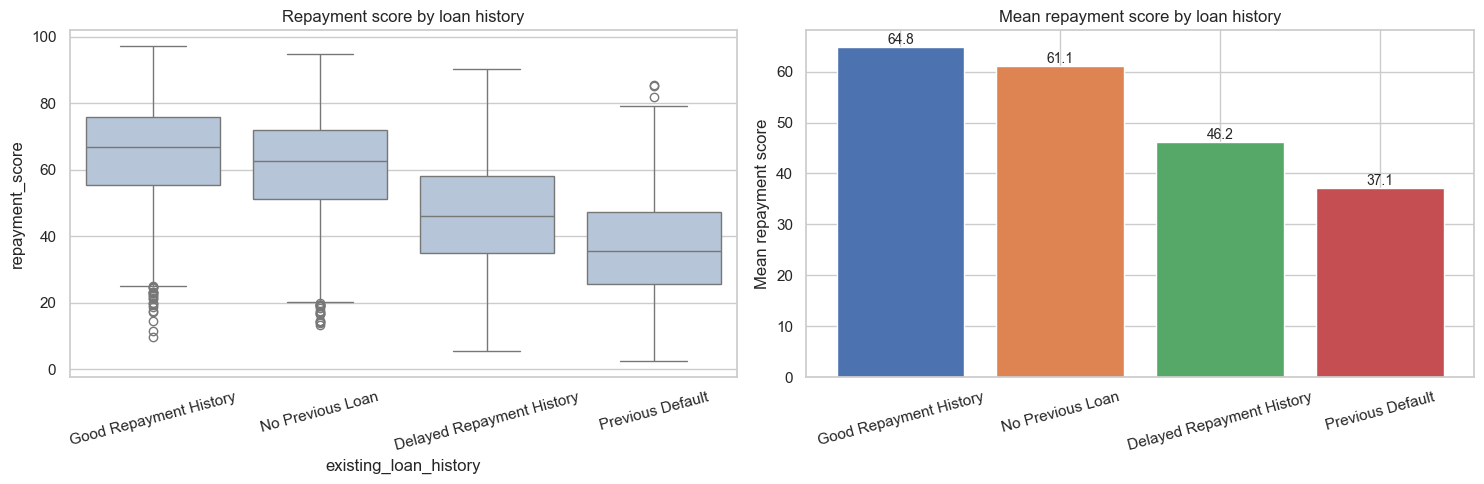

In [21]:
hist_order = hist.index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df, x="existing_loan_history", y="repayment_score",
            order=hist_order, ax=axes[0], color="lightsteelblue")
axes[0].set_title("Repayment score by loan history")
axes[0].tick_params(axis="x", rotation=15)
bars = axes[1].bar(hist_order, hist["mean_score"], color=sns.color_palette("deep", 4))
for bar, v in zip(bars, hist["mean_score"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v, f"{v:.1f}",
                 ha="center", va="bottom", fontsize=10)
axes[1].set_title("Mean repayment score by loan history")
axes[1].set_ylabel("Mean repayment score")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
save_fig(fig, "loan_history_repayment_score.png")
plt.show()

**Interpretation:** the relationship follows the expected logical pattern with a clean monotonic ordering across a ~28-point span:

| Category | Share | Mean score | Mean DTI |
|---|---|---|---|
| Good Repayment History | 29.8% | **64.85** | 0.18 |
| No Previous Loan | 46.9% | 61.13 | 0.10 |
| Delayed Repayment History | 16.4% | **46.17** | 0.31 |
| Previous Default | 6.9% | **37.07** | 0.41 |

Two realistic nuances: (1) "No Previous Loan" scores between Good and Delayed — absence of history is neutral-to-slightly-positive, not penalized like impairment; (2) impaired histories also carry much higher current DTI (0.31–0.41 vs 0.10–0.18), compounding their risk. The crosstab confirms `loan_history_code` is a **perfect 1:1 encoding** (0 = No Previous Loan, 1 = Good, 2 = Delayed, 3 = Default) — use one representation or the other in modeling, never both.

## 13. Outlier Analysis

IQR-based analysis (1.5 × IQR fences) and boxplots. **No outliers are removed** — in synthetic financial data, extreme-but-valid observations represent legitimate high-income or high-risk borrowers, and every value here lies inside its designed valid range.

,Q1,Q3,lower fence,upper fence,below,above,total,pct
variable,,,,,,,,
monthly_income,47336.50,83138.250,-6366.125,136840.875,0,274,274,2.74%
loan_size,391541.00,618462.000,51159.500,958843.500,1,251,252,2.52%
debt_to_income_ratio,0.08,0.261,-0.191,0.532,0,72,72,0.72%
digital_purchase_frequency,1.00,6.000,-6.500,13.500,0,1030,1030,10.30%
repayment_score,46.56,71.190,9.615,108.135,26,0,26,0.26%


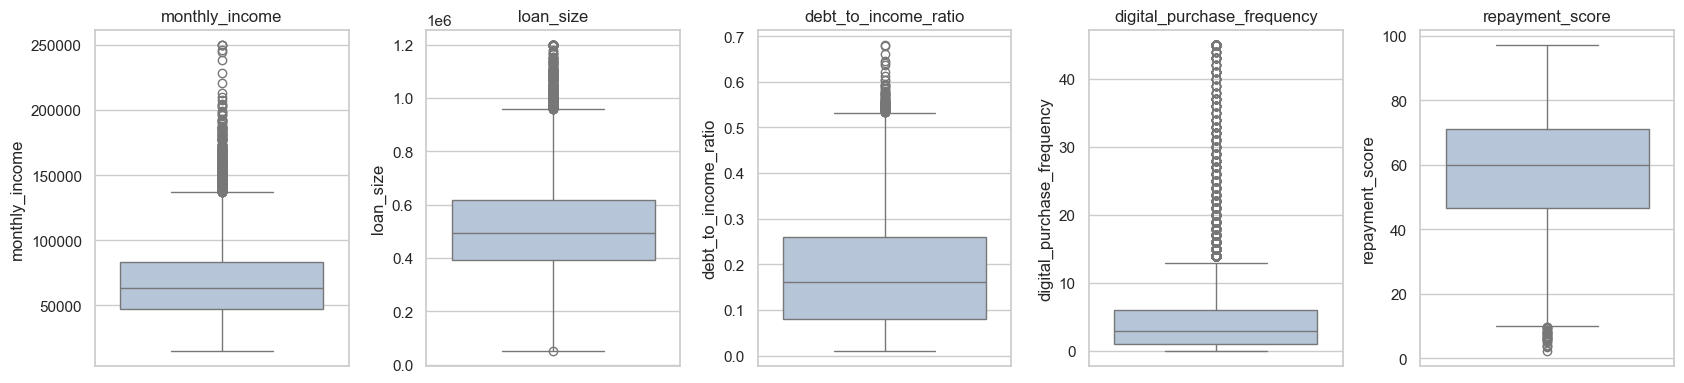

In [22]:
rows = []
for c in ["monthly_income", "loan_size", "debt_to_income_ratio",
          "digital_purchase_frequency", "repayment_score"]:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_lo, n_hi = int((df[c] < lo).sum()), int((df[c] > hi).sum())
    rows.append({"variable": c, "Q1": q1, "Q3": q3, "lower fence": lo, "upper fence": hi,
                 "below": n_lo, "above": n_hi, "total": n_lo + n_hi,
                 "pct": f"{(n_lo + n_hi)/len(df):.2%}"})
display(pd.DataFrame(rows).set_index("variable").round(3))

fig, axes = plt.subplots(1, 5, figsize=(17, 4))
for ax, c in zip(axes, ["monthly_income", "loan_size", "debt_to_income_ratio",
                        "digital_purchase_frequency", "repayment_score"]):
    sns.boxplot(y=df[c], ax=ax, color="lightsteelblue")
    ax.set_title(c)
plt.tight_layout()
plt.show()

**Findings:** IQR fences flag 2.74% of incomes (all on the high side, up to the 250,000 PKR cap), 2.52% of loan sizes, 0.72% of DTIs, 10.30% of digital purchase counts and 0.26% of repayment scores (all low-side). The high purchase-count share is expected: the IQR rule assumes symmetry, while this variable is strongly right-skewed count data. Every flagged value remains within its valid range, so **all are retained** — there is no evidence of invalid data, and the high-income/high-risk tails are exactly the population segments a credit model must handle.

## 14. Loan Burden Analysis

Derived analytical variable (EDA-only; the CSV is not modified):

`loan_burden = loan_size / (12 × monthly_income)` — the requested loan as a multiple of annual income.

In [23]:
df_eda = df.copy()  # working copy; original CSV untouched
df_eda["loan_burden"] = df_eda["loan_size"] / (12 * df_eda["monthly_income"])
lb = df_eda["loan_burden"]
print(f"Mean   : {lb.mean():.3f}")
print(f"Median : {lb.median():.3f}")
print(f"Std    : {lb.std():.3f}")
print(f"Min/Max: {lb.min():.3f} / {lb.max():.3f}")
print(f"Skew   : {lb.skew():.3f}")
print(f"\nCorrelation with repayment_score: Pearson = {lb.corr(df['repayment_score']):+.3f}, "
      f"Spearman = {lb.corr(df['repayment_score'], method='spearman'):+.3f}")
print(f"Correlation with monthly_income   : {lb.corr(df['monthly_income']):+.3f}")
print(f"Correlation with loan_size        : {lb.corr(df['loan_size']):+.3f}")

Mean   : 0.706
Median : 0.653
Std    : 0.295
Min/Max: 0.038 / 2.802
Skew   : 1.211

Correlation with repayment_score: Pearson = -0.453, Spearman = -0.439
Correlation with monthly_income   : -0.578
Correlation with loan_size        : +0.361


,count,mean,median
loan_burden,,,
<0.40,1086,70.16,72.62
0.40-0.60,3031,63.40,65.46
0.60-0.80,2809,58.01,59.68
0.80-1.00,1659,52.42,53.75
1.00-1.40,1135,46.18,46.46
>1.40,280,37.93,38.14


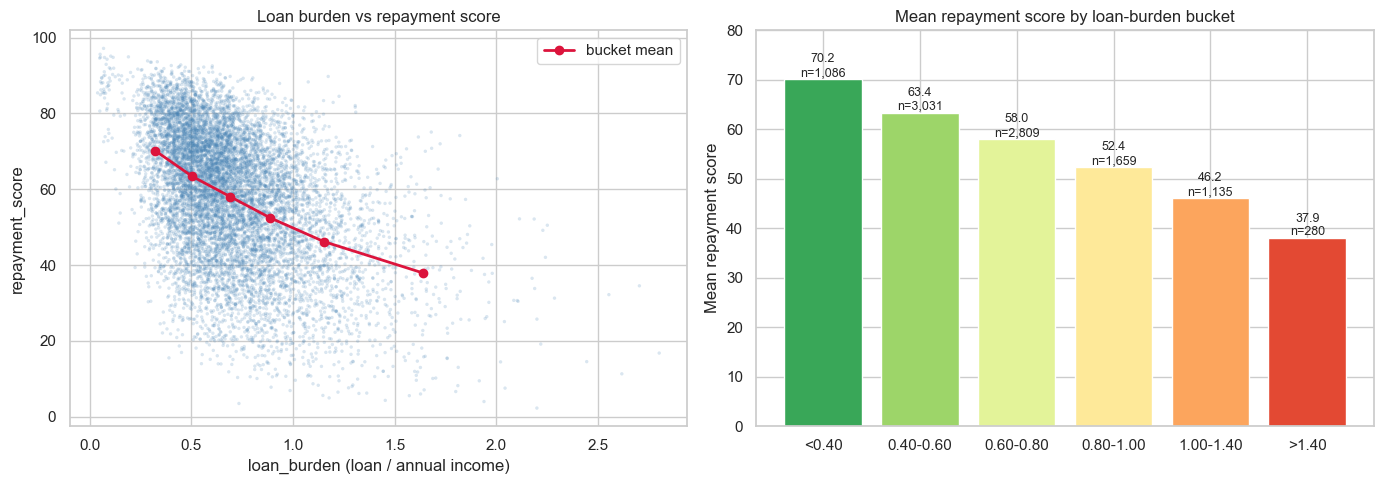

In [24]:
edges = [0, 0.40, 0.60, 0.80, 1.00, 1.40, np.inf]
labels = ["<0.40", "0.40-0.60", "0.60-0.80", "0.80-1.00", "1.00-1.40", ">1.40"]
buckets = pd.cut(lb, bins=edges, labels=labels, include_lowest=True)
bt = df_eda.groupby(buckets, observed=True)["repayment_score"].agg(["count", "mean", "median"])
display(bt.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(lb, df["repayment_score"], s=6, alpha=0.2, color="steelblue", edgecolors="none")
# binned-mean trend overlay
bin_mid = df_eda.groupby(buckets, observed=True)["loan_burden"].mean()
axes[0].plot(bin_mid.values, bt["mean"].values, "o-", color="crimson", lw=2, label="bucket mean")
axes[0].set_xlabel("loan_burden (loan / annual income)")
axes[0].set_ylabel("repayment_score")
axes[0].set_title("Loan burden vs repayment score")
axes[0].legend()
bars = axes[1].bar(labels, bt["mean"], color=sns.color_palette("RdYlGn", 6)[::-1])
for bar, (v, n) in zip(bars, zip(bt["mean"], bt["count"])):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v, f"{v:.1f}\nn={n:,}",
                 ha="center", va="bottom", fontsize=9)
axes[1].set_title("Mean repayment score by loan-burden bucket")
axes[1].set_ylabel("Mean repayment score")
axes[1].set_ylim(0, 80)
plt.tight_layout()
save_fig(fig, "loan_burden_vs_repayment_score.png")
plt.show()

**Findings:** loan burden averages 0.706 (median 0.653), is right-skewed to a maximum of 2.80, and is the **single strongest associate of the target among all measures examined (r = −0.453)** — stronger than raw income (+0.384) or raw loan size (−0.035). Mean repayment score falls monotonically and steeply across buckets: **70.16 → 63.40 → 58.01 → 52.42 → 46.18 → 37.93** (a 32-point drop from the lightest to the heaviest burden). Burden correlates −0.578 with income and +0.361 with loan size, i.e., it synthesizes both into the affordability signal the raw components only weakly show on their own.

## 15. Moderation Analysis

Loan size is intended as a **moderating variable**. Using loan burden as its analytical representation, we test whether the income → repayment-score relationship changes across burden levels. We distinguish a **direct relationship** (income ↔ score, all else equal) from an **interaction/moderation pattern** (the strength/level of that relationship depending on burden). No causal claims are made.

In [25]:
q33, q66 = lb.quantile([1/3, 2/3])
print(f"Burden tercile cut points: q33 = {q33:.3f}, q66 = {q66:.3f}")
grp = pd.cut(lb, bins=[-np.inf, q33, q66, np.inf], labels=["Low", "Moderate", "High"])
mod_tbl = df_eda.assign(grp=grp).groupby("grp", observed=True).agg(
    n=("repayment_score", "count"),
    mean_income=("monthly_income", "mean"),
    mean_burden=("loan_burden", "mean"),
    mean_score=("repayment_score", "mean"))
within_r = {}
for g in ["Low", "Moderate", "High"]:
    sub = df_eda[grp == g]
    within_r[g] = sub["monthly_income"].corr(sub["repayment_score"])
mod_tbl["income_score_r_within"] = pd.Series(within_r)
print(f"\nOverall income-score correlation (pooled): "
      f"{df['monthly_income'].corr(df['repayment_score']):+.3f}")
display(mod_tbl.round(3))

Burden tercile cut points: q33 = 0.551, q66 = 0.778

Overall income-score correlation (pooled): +0.384


,n,mean_income,mean_burden,mean_score,income_score_r_within
grp,,,,,
Low,3334,89358.481,0.428,66.086,0.201
Moderate,3333,66727.236,0.657,59.097,0.207
High,3333,49047.772,1.034,49.203,0.260


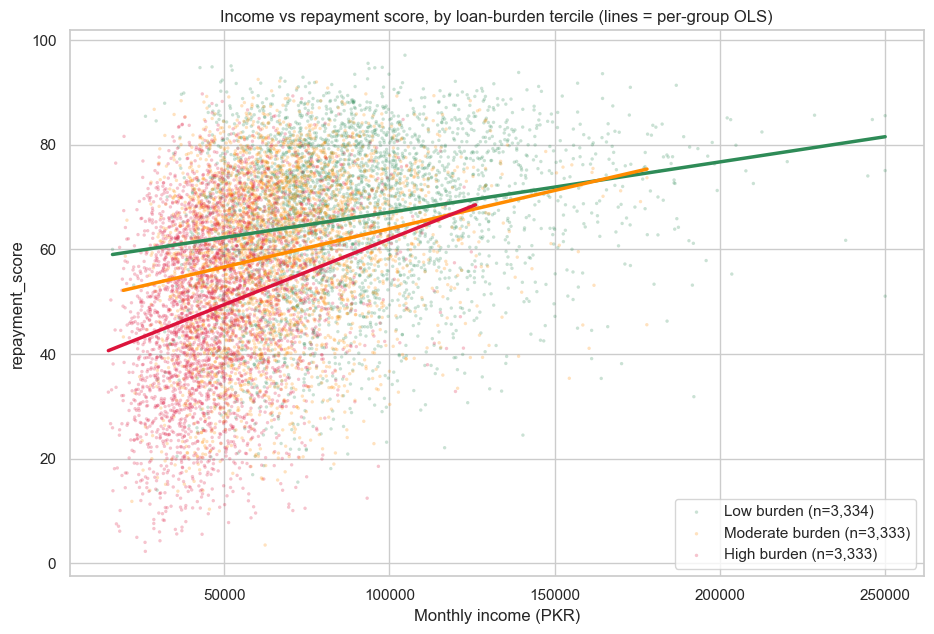

,lower income half,upper income half,gap
bucket,,,
<0.40,69.52,70.23,0.71
0.40-0.60,58.96,65.11,6.15
0.60-0.80,55.42,61.02,5.60
0.80-1.00,51.21,56.15,4.94
1.00-1.40,45.59,50.89,5.31
>1.40,37.89,42.03,4.14


In [26]:
fig, ax = plt.subplots(figsize=(9.5, 6.5))
colors = {"Low": "seagreen", "Moderate": "darkorange", "High": "crimson"}
for g in ["Low", "Moderate", "High"]:
    sub = df_eda[grp == g]
    ax.scatter(sub["monthly_income"], sub["repayment_score"], s=6, alpha=0.25,
               color=colors[g], edgecolors="none", label=f"{g} burden (n={len(sub):,})")
    m, b = np.polyfit(sub["monthly_income"], sub["repayment_score"], 1)
    xs = np.linspace(sub["monthly_income"].min(), sub["monthly_income"].max(), 50)
    ax.plot(xs, m * xs + b, color=colors[g], lw=2.5)
ax.set_xlabel("Monthly income (PKR)")
ax.set_ylabel("repayment_score")
ax.set_title("Income vs repayment score, by loan-burden tercile (lines = per-group OLS)")
ax.legend()
plt.tight_layout()
plt.show()

# Income-half gap within each burden bucket
med_inc = df["monthly_income"].median()
halves = df_eda.assign(bucket=buckets, upper=df_eda["monthly_income"] > med_inc)
gap_tbl = halves.pivot_table(index="bucket", columns="upper",
                             values="repayment_score", observed=True)
gap_tbl.columns = ["lower income half", "upper income half"]
gap_tbl["gap"] = gap_tbl["upper income half"] - gap_tbl["lower income half"]
display(gap_tbl.round(2))

**Moderation findings:**

- **Pooled vs within-group:** the overall income↔score correlation is +0.384, but **within** burden terciles it drops to +0.201 (Low), +0.207 (Moderate) and +0.260 (High). More than half of the raw income–score association therefore flows **through the burden channel** (income ↔ burden = −0.578): higher income raises scores largely because it lowers loan burden.
- **Level shifts:** mean score falls sharply across terciles — 66.09 (Low) → 59.10 (Moderate) → 49.20 (High) — a 17-point drop independent of any within-group slope.
- **Income-half gap by bucket:** the score gap between upper- and lower-income halves widens from just **0.7 points** in the lightest bucket (<0.40) to **4–6 points** in moderate/high buckets. At minimal burden, income barely differentiates scores; at meaningful burden, income starts to matter.

**Conclusion:** the moderation in this dataset manifests primarily as **level (intercept) shifts plus attenuation of the pooled income effect**, rather than as a reversal or strong progressive weakening of within-group slopes. In plain terms: *a big loan relative to income drags the score down for everyone, and it also hides much of the advantage a high income would otherwise show* — exactly the moderating role the generation design intended (interaction terms between burden and DTI / loan history). This is an observed interaction pattern, not a causal estimate.

## 16. Nonlinear Relationships

Scatter + binned-mean overlays for the four relationships most likely to be nonlinear. Relationships are only called nonlinear where the data supports it.

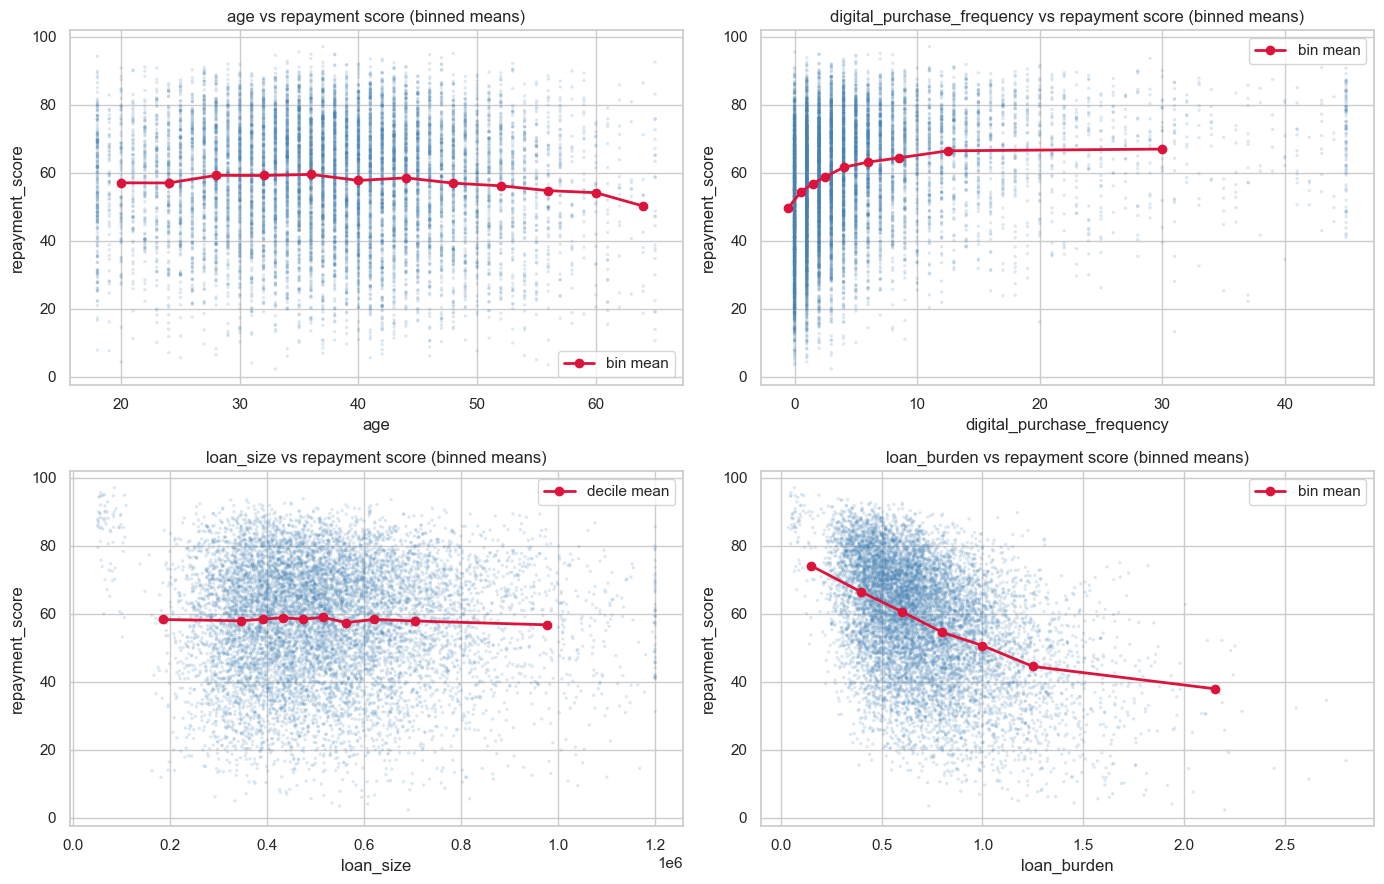

Age binned means:
age
(17.999, 22.0]    57.04
(22.0, 26.0]      57.00
(26.0, 30.0]      59.23
(30.0, 34.0]      59.20
(34.0, 38.0]      59.51
(38.0, 42.0]      57.74
(42.0, 46.0]      58.49
(46.0, 50.0]      56.94
(50.0, 54.0]      56.15
(54.0, 58.0]      54.73
(58.0, 62.0]      54.13
(62.0, 66.0]      50.20


In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

def binned_mean_line(ax, x, y, bins, label):
    grp = pd.cut(x, bins=bins, include_lowest=True)
    means = y.groupby(grp, observed=True).mean()
    centers = [iv.mid for iv in means.index]
    ax.plot(centers, means.values, "o-", color="crimson", lw=2, label=label)

panels = [
    ("age", np.arange(18, 71, 4)),
    ("digital_purchase_frequency", [-1, 0, 1, 2, 3, 5, 7, 10, 15, 45]),
    ("loan_size", None),   # deciles
    ("loan_burden", [0, 0.3, 0.5, 0.7, 0.9, 1.1, 1.4, 2.9]),
]
for ax, (col, bins) in zip(axes.ravel(), panels):
    x = df_eda[col]
    ax.scatter(x, df_eda["repayment_score"], s=6, alpha=0.18, color="steelblue", edgecolors="none")
    if bins is None:
        grp = pd.qcut(x, 10)
        means = df_eda["repayment_score"].groupby(grp, observed=True).mean()
        centers = [iv.mid for iv in means.index]
        ax.plot(centers, means.values, "o-", color="crimson", lw=2, label="decile mean")
    else:
        binned_mean_line(ax, x, df_eda["repayment_score"], bins, "bin mean")
    ax.set_xlabel(col)
    ax.set_ylabel("repayment_score")
    ax.set_title(f"{col} vs repayment score (binned means)")
    ax.legend()
plt.tight_layout()
plt.show()

print("Age binned means:")
print(df_eda["repayment_score"].groupby(pd.cut(df_eda["age"], np.arange(18, 71, 4),
      include_lowest=True), observed=True).mean().round(2).to_string())

**Findings:**

- **Age — mildly nonlinear (inverted-U then decline):** mean score rises from 57.0 (18–25) to a peak of ~59.4 (30–35), drifts down through middle age and falls notably to 49.9 for 60–65. Near-zero linear correlation (−0.036) coexists with a visible life-cycle shape — a good argument for tree-based models or explicit age binning.
- **Digital purchase frequency — positive and concave:** mean score climbs steadily from 49.7 (0 purchases) to ~64 by 7–10 purchases, then **flattens** (66.5 at 10–15, 67.0 at 15+). The relationship is monotone but bends — consistent with Spearman (+0.338) exceeding Pearson (+0.254).
- **Loan size — effectively flat:** decile means stay within 56.7–59.0 with the top decile lowest. Raw loan size shows **no meaningful marginal relationship**; its influence is conditional on income via loan burden (§14) — the defining behavior of a moderating variable.
- **Loan burden — strongly monotonic (near-linear decline):** binned means fall continuously with no plateau — the steepest, most consistent gradient in the dataset.

## 17. Fairness / Demographic Exploration

`gender` and `province` were generated independently of all predictors and the target (fairness by construction). This section provides the **exploratory baseline audit** for the later ML stage. No discrimination or causality is inferred from synthetic data.


Repayment score by gender:


,count,mean,median,std
gender,,,,
Female,3851,57.64,58.98,17.13
Male,6149,58.44,60.60,17.10



Repayment score by province:


,count,mean,median,std
province,,,,
Balochistan,706,57.93,59.92,17.76
Khyber Pakhtunkhwa,1699,58.10,60.05,16.99
Punjab,5286,58.11,59.92,17.08
Sindh,2309,58.25,60.20,17.11


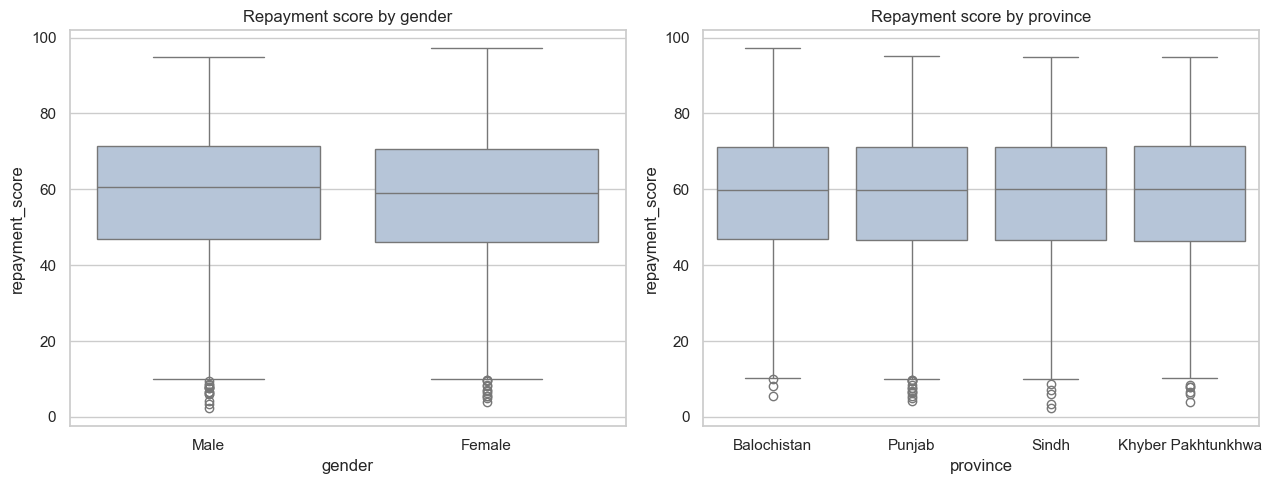

In [28]:
for c in ["gender", "province"]:
    print(f"\nRepayment score by {c}:")
    display(df.groupby(c)["repayment_score"].agg(["count", "mean", "median", "std"]).round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df, x="gender", y="repayment_score", ax=axes[0], color="lightsteelblue")
axes[0].set_title("Repayment score by gender")
sns.boxplot(data=df, x="province", y="repayment_score", ax=axes[1], color="lightsteelblue")
axes[1].set_title("Repayment score by province")
plt.tight_layout()
plt.show()

**Findings:** Female borrowers average 57.64 (median 58.98) vs Male 58.44 (median 60.60) — a mean gap of **0.80 points (≈ 0.05 SD)**. Province means span just 57.93–58.25 (Balochistan to Sindh, a 0.32-point range). Both gaps are negligible and consistent with the demographic columns being generated independently — a clean fairness **baseline**: any group disparity that appears after model training would be attributable to the modeling pipeline, not the data.

## 18. Data Leakage Check

Classification of every column by its role, ahead of ML training:

In [29]:
roles = pd.DataFrame([
    ("borrower_id",            "ID — drop before training"),
    ("age",                    "legitimate predictor"),
    ("occupation",             "legitimate predictor (needs categorical encoding)"),
    ("monthly_income",         "legitimate predictor"),
    ("existing_loan_history",  "legitimate predictor (needs categorical encoding)"),
    ("loan_history_code",      "DUPLICATE ENCODING of existing_loan_history — never use both"),
    ("debt_to_income_ratio",   "legitimate predictor"),
    ("loan_size",              "legitimate predictor (moderating variable)"),
    ("telecom_usage_score",    "legitimate predictor"),
    ("mobile_wallet_activity", "legitimate predictor"),
    ("digital_purchase_frequency", "legitimate predictor"),
    ("psychometric_score",     "legitimate predictor"),
    ("gender",                 "demographic — exclude from predictors (fairness audit only)"),
    ("province",               "demographic — exclude from predictors (fairness audit only)"),
    ("repayment_score",        "TARGET — must never be used as an input feature"),
], columns=["column", "role"])
display(roles)

ct = pd.crosstab(df["existing_loan_history"], df["loan_history_code"])
perfect = (((ct > 0).sum(axis=1) == 1).all() and ((ct > 0).sum(axis=0) == 1).all())
print("loan_history_code is a perfect 1:1 encoding of existing_loan_history:", perfect)
print("loan_burden is derived only from loan_size and monthly_income (no target information): True")

,column,role
0,borrower_id,ID — drop before training
1,age,legitimate predictor
2,occupation,legitimate predictor (needs categorical encoding)
3,monthly_income,legitimate predictor
4,existing_loan_history,legitimate predictor (needs categorical encoding)
5,loan_history_code,DUPLICATE ENCODING of existing_loan_history — ...
6,debt_to_income_ratio,legitimate predictor
7,loan_size,legitimate predictor (moderating variable)
8,telecom_usage_score,legitimate predictor
9,mobile_wallet_activity,legitimate predictor


loan_history_code is a perfect 1:1 encoding of existing_loan_history: True
loan_burden is derived only from loan_size and monthly_income (no target information): True


**Leakage verdict:** the only true leakage risks are (1) using `repayment_score` as an input — forbidden, it is the target; (2) using `loan_history_code` **and** `existing_loan_history` together — they are the same information twice (verified 1:1 above), which inflates importance and destabilizes linear coefficients. `loan_burden` is a **derived analytical variable** built only from `loan_size` and `monthly_income` — it contains no target information and is safe (and recommended) to engineer during preprocessing. Gender and province are excluded from predictors and reserved for fairness evaluation.

## 19. Key EDA Findings

1. **Dataset quality — clean.** 10,000 rows × 15 columns; 0 missing values, 0 duplicate rows/IDs; valid datatypes; **all 8 range constraints PASS**; `loan_history_code` verified as a perfect 1:1 encoding of `existing_loan_history`.
2. **Target distribution — regression-ready.** `repayment_score`: mean 58.1, median 60.0, std 17.1, range 2.27–97.15, skew −0.43; bands: Very Low 2.0%, Low 14.3%, Moderate 33.7%, High 41.1%, Very High 8.9%. Unimodal, thin extremes, no boundary pile-ups.
3. **Most important numerical relationships (with the target).** DTI −0.486 (strongest), income +0.384, psychometric +0.341, telecom +0.300, wallet +0.300, digital purchases +0.254 (Spearman +0.338 → nonlinear), loan size −0.035 and age −0.036 (both near-zero marginally).
4. **Categorical relationships.** Loan history spans ~28 points (Good 64.85 → Default 37.07; No Previous Loan 61.13 sits in between — neutral, not penalized). Occupation spans ~11.5 points (Business Owner 62.96 → Daily Wage Worker 51.46), tracking income almost perfectly while DTI stays flat (0.17–0.20).
5. **Feature-feature relationships.** wallet ↔ digital purchases **+0.611** (Spearman +0.706) — main multicollinearity candidate; income ↔ loan size +0.430; loan ↔ DTI −0.270; income ↔ DTI −0.132 (weak). No pair exceeds |r| = 0.7.
6. **Outliers.** IQR flags 2.74% of incomes, 2.52% of loans, 0.72% of DTIs, 10.30% of purchase counts (expected for skewed count data), 0.26% of scores. All within valid ranges → **retained**; the tails are legitimate high-income/high-risk segments.
7. **Loan burden behavior.** Mean 0.706, median 0.653, range 0.038–2.80; correlation with score **−0.453** — the strongest single association found; bucket means fall 70.16 → 37.93 monotonically.
8. **Evidence of moderation.** Pooled income↔score r = +0.384 collapses to +0.20…+0.26 within burden terciles; mean score drops 66.09 → 49.20 across terciles; the income-half score gap widens from 0.7 to 4–6 points as burden rises. Loan size acts as a moderating variable whose effect materializes through burden **level shifts**, while raw loan size alone is marginally flat — exactly the intended design.
9. **Preprocessing considerations.** Encode `occupation` (one-hot) and `existing_loan_history` (one-hot or ordinal 0–3, dropping the duplicate code column); consider log-transforming income/loan size/purchase counts for linear baselines; **engineer `loan_burden`** (and optionally income×burden interactions) for linear models — trees learn these natively; no imputation or outlier removal needed.
10. **ML concerns.** Continuous target → regression (MAE, RMSE, R², predicted-vs-actual correlation); wallet/purchase collinearity affects linear baselines; exclude `gender`/`province` from predictors (keep for fairness audit); never feed the target or both history encodings into the model; suggested protocol: 80/20 split + 5-fold cross-validation, mirroring the paper's methodology.

## 20. Machine Learning Preparation Notes (no training performed)

**Predictors (10):** `age`, `occupation`, `monthly_income`, `existing_loan_history`, `debt_to_income_ratio`, `loan_size`, `telecom_usage_score`, `mobile_wallet_activity`, `digital_purchase_frequency`, `psychometric_score`

**Target:** `repayment_score` (continuous, 0–100)

**Drop before training:**
- `borrower_id` — identifier only
- `loan_history_code` — duplicate encoding of `existing_loan_history` (keep one, not both)
- `gender`, `province` — demographic columns excluded from prediction; retain separately **only** for a fairness experiment

**Encoding required:**
- `occupation` — nominal, 6 levels → one-hot encoding
- `existing_loan_history` — ordinal by impairment (No Previous Loan < Good < Delayed < Default is *not* a quality ordering; treat as nominal one-hot, or map to an ordinal risk scale deliberately)

**Recommended engineered features (from EDA evidence):**
- `loan_burden = loan_size / (12 × monthly_income)` — strongest single associate (−0.453)
- Optional interactions: burden × DTI, burden × loan history (the moderation channels found in §15)
- Optional log transforms of `monthly_income`, `loan_size`, `digital_purchase_frequency` for the linear baseline

**Suggested evaluation protocol:** 80/20 train/test split with 5-fold cross-validation on the training set; metrics MAE, RMSE, R² and predicted-vs-actual correlation — mirroring the methodology of Khan et al. (2025) adapted to the continuous target.

---

*End of EDA — no models were trained, no splits were made, and the original CSV was not modified.*